100%|██████████| 170498071/170498071 [00:04<00:00, 35120912.24it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Epoch 1, Loss: 2519.1046423046873
Epoch 2, Loss: 1138.9210247265626
Epoch 3, Loss: 978.5207078515625
Epoch 4, Loss: 902.4985898828126
Epoch 5, Loss: 873.8804115234375
Epoch 6, Loss: 854.10591421875
Epoch 7, Loss: 840.5424901953126
Epoch 8, Loss: 828.7814661523438
Epoch 9, Loss: 817.7021409375
Epoch 10, Loss: 811.6452096875


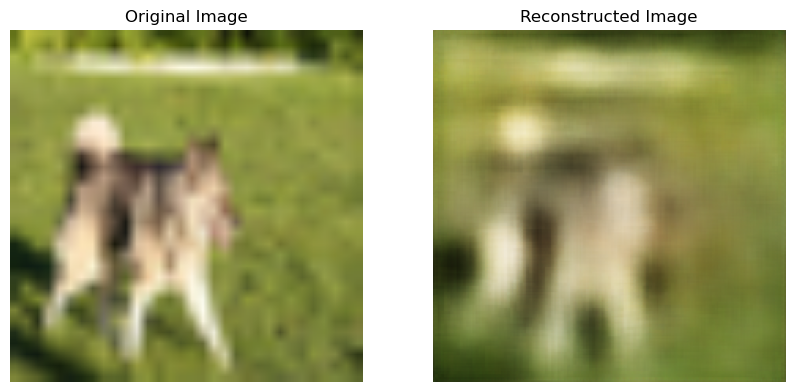

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# VAE 모델 정의
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)  # Mean
        self.fc2 = nn.Linear(64 * 56 * 56, 128)  # Log Var
        self.fc3 = nn.Linear(128, 64 * 56 * 56)  # Decoder input

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)

    def encode(self, x):
        h1 = F.relu(self.conv1(x))
        h2 = F.relu(self.conv2(h1))
        h3 = h2.view(h2.size(0), -1)  # Flatten
        return self.fc1(h3), self.fc2(h3)  # Mean and log variance

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Standard deviation
        eps = torch.randn_like(std)  # Random noise
        return mu + eps * std

    def decode(self, z):
        h3 = self.fc3(z).view(-1, 64, 56, 56)  # Reshape
        h4 = F.relu(self.deconv1(h3))
        return torch.sigmoid(self.deconv2(h4))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        BCE = F.mse_loss(recon_x, x, reduction='sum')  # Reconstruction loss
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence
        return BCE + KLD

# 데이터셋 로드 및 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# CIFAR-10 데이터셋 예시 사용 (224x224 이미지)
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# VAE 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = model.loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

# 테스트(예시로 하나의 이미지 출력)
model.eval()
with torch.no_grad():
    sample_image = data[0].unsqueeze(0).to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, _, _ = model(sample_image)

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

In [ ]:
# Add ../ as a directory to import from
import sys
sys.path.append('../')
from src.plant_dataset import PlantDataset, collate_fn

stages = ["003", "010", "016", "023"]
#train_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages[0],
train_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages,
                            transform=transform, load_depth=False, preload=True, process_leaf=True, image_size=224)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# VAE 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Total 7951 images and plant strings loaded
Pre-loading data


 39%|███▊      | 3066/7951 [01:59<04:06, 19.80it/s]

Epoch 1, Loss: 1424.3861800275301
Epoch 2, Loss: 1322.1658200052439
Epoch 3, Loss: 1253.1461392239119
Epoch 4, Loss: 1193.6197582098846
Epoch 5, Loss: 1151.9374713227583
Epoch 6, Loss: 1120.2545084720766
Epoch 7, Loss: 1088.000270385422
Epoch 8, Loss: 1064.390205083246
Epoch 9, Loss: 1047.9822098682484
Epoch 10, Loss: 1064.2159662591766
Epoch 11, Loss: 1071.1539046113005
Epoch 12, Loss: 992.0183247574724
Epoch 13, Loss: 970.5733051750132
Epoch 14, Loss: 951.2323778349502
Epoch 15, Loss: 954.332485989119
Epoch 16, Loss: 1004.6632206181174
Epoch 17, Loss: 991.7422202739906
Epoch 18, Loss: 931.9354208999738
Epoch 19, Loss: 899.2216976107761
Epoch 20, Loss: 894.4223215456213
Epoch 21, Loss: 900.4309923144992
Epoch 22, Loss: 906.9109899383849
Epoch 23, Loss: 869.4927917704509
Epoch 24, Loss: 849.2193481253278
Epoch 25, Loss: 849.01383676914
Epoch 26, Loss: 852.9421539066597
Epoch 27, Loss: 841.0603758357367
Epoch 28, Loss: 827.1150961097273
Epoch 29, Loss: 824.9231122181437
Epoch 30, Loss: 

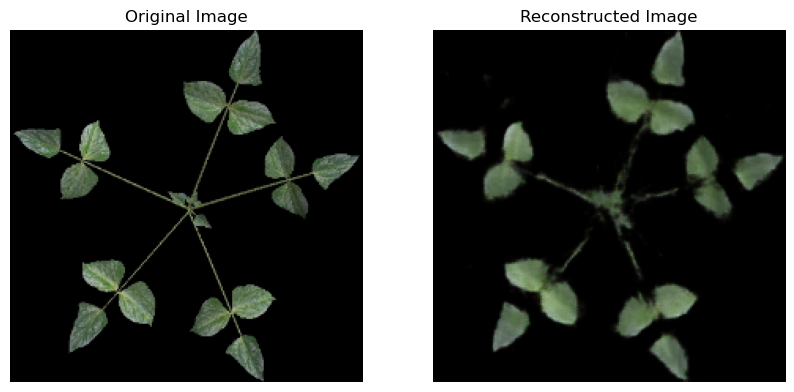

In [8]:
# Training Loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = model.loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

# 테스트(예시로 하나의 이미지 출력)
model.eval()
with torch.no_grad():
    sample_image = data[0].unsqueeze(0).to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, _, _ = model(sample_image)

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

In [9]:

# 테스트(예시로 하나의 이미지 출력)
model.eval()
with torch.no_grad():
    sample_image = data[0].unsqueeze(0).to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, mu, logvar = model(sample_image)

In [12]:
print(mu.shape)
print(logvar.shape)

torch.Size([1, 128])
torch.Size([1, 128])
